In [26]:
import numpy as np
import torch
import time
import matplotlib.pyplot as plt

In [27]:
def chebyshev_cgl(N):
    j = torch.arange(0, N+1, dtype=torch.float64)
    x = torch.cos(torch.pi * j / N)
    return x

In [28]:
def chebyshev_diff_matrix(N):
    x = chebyshev_cgl(N)
    
    c = torch.ones(N+1, dtype=torch.float64)
    c[0] = 2.0
    c[-1] = 2.0
    
    X = x.unsqueeze(0)
    dX = X.T - X
    
    C = c.unsqueeze(0)
    C_ratio = C.T / C
    
    i = torch.arange(N+1)
    sign = (-1.0) ** (i.unsqueeze(0) + i.unsqueeze(1))
    
    dX = dX + torch.eye(N+1)
    
    D = C_ratio * sign / dX
    D = D - torch.diag(torch.sum(D, dim=1))
    
    return x, D

In [29]:
def build_A(D, bc_weight=10.0):
    D2 = D @ D
    A_pde = -D2
    
    Np1 = D.shape[0]
    A_bc = torch.zeros(2, Np1, dtype=D.dtype)
    
    A_bc[0, 0] = bc_weight
    A_bc[1, -1] = bc_weight
    
    A = torch.cat([A_pde, A_bc], dim=0)
    
    return A

In [30]:
N = 100   # you can vary later

x, D = chebyshev_diff_matrix(N)
A = build_A(D, bc_weight=10.0)

A_np = A.detach().cpu().numpy()

print("A shape:", A_np.shape)

A shape: (103, 101)


In [31]:
def A_block(row_idx, col_idx):
    return A_np[np.ix_(row_idx, col_idx)]

In [32]:
N_rows, N_cols = A_np.shape

x_rows = np.arange(N_rows)
x_cols = np.arange(N_cols)

v_test = np.random.randn(N_cols)

In [33]:
print("Computing exact A @ v ...")

t0 = time.perf_counter()
y_exact = A_np @ v_test
t1 = time.perf_counter()

print("Exact time:", t1 - t0)

norm_exact = np.linalg.norm(y_exact)

Computing exact A @ v ...
Exact time: 0.0002786660334095359


In [38]:
class RectangularHODLR:
    def __init__(self, n_rows, n_cols, block_fn, p=8, max_level=4, leaf_size=64):
        self.n_rows = n_rows
        self.n_cols = n_cols
        self.block_fn = block_fn
        self.p = p
        self.max_level = max_level
        self.leaf_size = leaf_size
        
        self.blocks = []
        self._build(0, self.n_rows, 0, self.n_cols, level=0)

    def _low_rank_approx(self, r0, r1, c0, c1):
        submat = self.block_fn(np.arange(r0, r1), np.arange(c0, c1))
        
        # SVD-based low rank
        U, S, Vt = np.linalg.svd(submat, full_matrices=False)
        
        k = min(self.p, len(S))
        U_k = U[:, :k]
        S_k = np.diag(S[:k])
        V_k = Vt[:k, :]
        
        return U_k, S_k, V_k

    def _build(self, r0, r1, c0, c1, level):
        is_far = (r1 <= c0) or (c1 <= r0)

        if is_far and level > 0:
            U, S, V = self._low_rank_approx(r0, r1, c0, c1)
            self.blocks.append(('lowrank', (r0, r1), (c0, c1), U, S, V))

        elif level >= self.max_level or (r1 - r0) <= self.leaf_size:
            mat = self.block_fn(np.arange(r0, r1), np.arange(c0, c1))
            self.blocks.append(('dense', (r0, r1), (c0, c1), mat))

        else:
            rmid = (r0 + r1) // 2
            cmid = (c0 + c1) // 2

            self._build(r0, rmid, c0, cmid, level + 1)
            self._build(r0, rmid, cmid, c1, level + 1)
            self._build(rmid, r1, c0, cmid, level + 1)
            self._build(rmid, r1, cmid, c1, level + 1)

    def matvec(self, v):
        y = np.zeros(self.n_rows)

        for kind, r_range, c_range, *data in self.blocks:
            r0, r1 = r_range
            c0, c1 = c_range

            if kind == 'dense':
                y[r0:r1] += data[0] @ v[c0:c1]
            else:
                U, S, V = data
                y[r0:r1] += U @ (S @ (V @ v[c0:c1]))

        return y

In [39]:
v = np.random.randn(A.shape[1])

# Exact
t0 = time.time()
y_exact = A @ v
t1 = time.time()

# HODLR
H = RectangularHODLR(A.shape[0], A.shape[1], A_block, p=8, max_level=4)

t2 = time.time()
y_hodlr = H.matvec(v)
t3 = time.time()

# Error
rel_error = np.linalg.norm(y_exact - y_hodlr) / np.linalg.norm(y_exact)

print("Relative Error:", rel_error)
print("Exact time:", t1 - t0)
print("HODLR time:", t3 - t2)

Relative Error: 7.567526238477141e-11
Exact time: 0.0009560585021972656
HODLR time: 8.130073547363281e-05


/var/folders/01/clqj4wcd2qq03ync59x2wd5c0000gn/T/ipykernel_48655/180065854.py:5: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_exact = A @ v
/var/folders/01/clqj4wcd2qq03ync59x2wd5c0000gn/T/ipykernel_48655/180065854.py:16: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rel_error = np.linalg.norm(y_exact - y_hodlr) / np.linalg.norm(y_exact)


In [40]:
ranks = [2, 4, 6, 8, 12, 16]
errors = []
times = []

for p in ranks:
    t0 = time.time()
    
    H = RectangularHODLR(A.shape[0], A.shape[1], A_block, p=p, max_level=4)
    y_hodlr = H.matvec(v)
    
    t1 = time.time()
    
    err = np.linalg.norm(y_exact - y_hodlr) / np.linalg.norm(y_exact)
    
    errors.append(err)
    times.append(t1 - t0)
    
    print(f"p={p}, error={err:.2e}, time={t1-t0:.4f}")

p=2, error=2.89e-06, time=0.0012
p=4, error=1.23e-06, time=0.0009
p=6, error=3.06e-09, time=0.0003
p=8, error=7.57e-11, time=0.0002
p=12, error=3.42e-16, time=0.0002
p=16, error=1.48e-16, time=0.0002


/var/folders/01/clqj4wcd2qq03ync59x2wd5c0000gn/T/ipykernel_48655/1530477039.py:13: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  err = np.linalg.norm(y_exact - y_hodlr) / np.linalg.norm(y_exact)


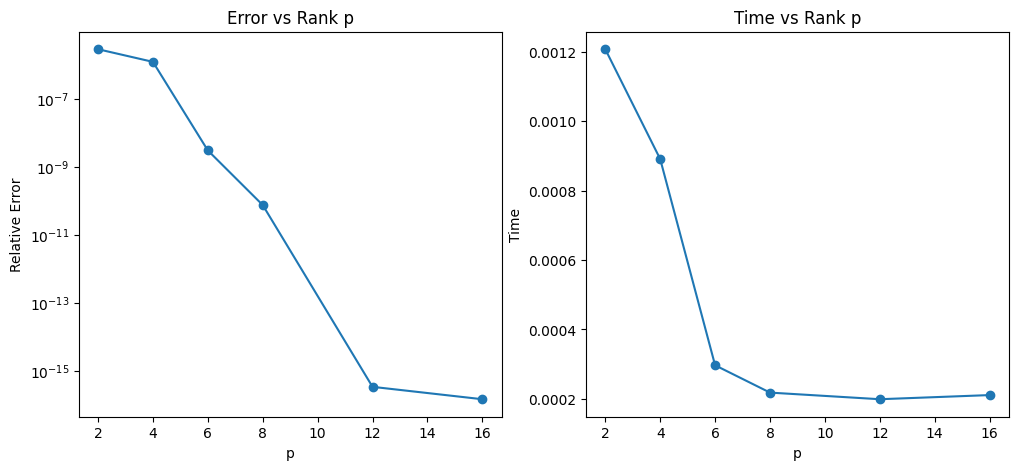

In [41]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(ranks, errors, 'o-')
plt.yscale('log')
plt.title("Error vs Rank p")
plt.xlabel("p")
plt.ylabel("Relative Error")

plt.subplot(1,2,2)
plt.plot(ranks, times, 'o-')
plt.title("Time vs Rank p")
plt.xlabel("p")
plt.ylabel("Time")

plt.show()